In [11]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/egu-2025/egu_2025'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/egu-2025/egu_2025/error correction.txt
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Road_Density_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_NDVI90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Relative_Relief90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Geology_Lookup_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Slope90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Drain_Density_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Dist_to_Hill90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Landform_Lookup_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Aspect90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_TWI_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Curvature90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_Geomorph_WG_Lookup_tif90.tif
/kaggle/input/egu-2025/egu_2025/Raster Data/Raigad_DistanceToLineaments_tif90.tif
/kaggle/input/egu-2

## Importing libraries

In [1]:
!pip install -q rasterio geopandas openpyxl
!pip install -q transformers accelerate bitsandbytes peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 57.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━

## Stage 1: Base Model Pre-training & Traditional Benchmarks

In [4]:
"""
================================================================================
ConvLSTM-Based Spatiotemporal Landslide Susceptibility Mapping
Raigad District, Maharashtra, India - FINAL VERSION
================================================================================
Author: Research Project
Description: Deep learning framework for landslide susceptibility forecasting
             integrating 8-year LULC dynamics (2017-2024) with 19 conditioning factors
Version: 1.1 - Fixed dimension mismatch and removed unused imports
================================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Geospatial libraries
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import Point, box
from scipy.spatial.distance import cdist
from scipy.ndimage import zoom
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

# ML and evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             matthews_corrcoef, classification_report, roc_curve)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Project configuration parameters"""

    # Paths
    BASE_PATH = "/kaggle/input/egu-2025/egu_2025/"
    RASTER_PATH = os.path.join(BASE_PATH, "Raster Data")
    LULC_PATH = os.path.join(BASE_PATH, "Optional_LULC")
    RAINFALL_PATH = os.path.join(BASE_PATH, "Rainfall Data")
    SHAPEFILE_PATH = os.path.join(BASE_PATH, "Shapefile")
    LS_INVENTORY_PATH = os.path.join(BASE_PATH, "Shapefile/LSInventory/Raigad_LS.shp")
    OUTPUT_PATH = "./outputs/"

    # Sampling parameters
    PATCH_SIZE = 32  # Size of patches to extract
    BUFFER_DISTANCE = 500  # meters - minimum distance for non-landslide samples
    NEGATIVE_RATIO = 1.0  # Ratio of negative to positive samples (1.0 = balanced)

    # Model parameters
    IMAGE_SIZE = (256, 256)  # Will be adjusted based on actual data
    TEMPORAL_STEPS = 8  # 2017-2024
    NUM_FEATURES = 20  # Conditioning factors (19 + 1 LULC)
    BATCH_SIZE = 32  # Increased for P100 GPU
    EPOCHS = 100
    # LEARNING_RATE = 0.001
    LEARNING_RATE = 0.0005

    # ConvLSTM architecture
    CONVLSTM_LAYERS = [64, 128, 128, 64]
    KERNEL_SIZE = (3, 3)

    # Data split
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create output directory
    os.makedirs(OUTPUT_PATH, exist_ok=True)

config = Config()

print(f"Device: {config.DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Output directory: {config.OUTPUT_PATH}")

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def resize_array(array, target_shape):
    """Resize array to target shape using nearest neighbor interpolation"""

    if array.shape == target_shape:
        return array

    zoom_factors = (target_shape[0] / array.shape[0], 
                   target_shape[1] / array.shape[1])

    # Handle NaN values
    nan_mask = np.isnan(array)
    array_filled = np.where(nan_mask, 0, array)

    # Resize
    resized = zoom(array_filled, zoom_factors, order=0)  # order=0 = nearest neighbor

    # Restore NaN mask
    mask_resized = zoom(nan_mask.astype(float), zoom_factors, order=0) > 0.5
    resized = np.where(mask_resized, np.nan, resized)

    return resized

# ============================================================================
# LANDSLIDE INVENTORY LOADER
# ============================================================================

class LandslideInventoryLoader:
    """Load and process landslide inventory"""

    def __init__(self, inventory_path, transform, raster_shape, raster_crs):
        self.inventory_path = inventory_path
        self.transform = transform
        self.raster_shape = raster_shape
        self.raster_crs = raster_crs

    def load_inventory(self):
        """Load landslide inventory shapefile"""
        print("\n" + "="*80)
        print("LOADING LANDSLIDE INVENTORY")
        print("="*80)

        try:
            ls_gdf = gpd.read_file(self.inventory_path)
            print(f"  Loaded: {os.path.basename(self.inventory_path)}")
            print(f"  Original CRS: {ls_gdf.crs}")
            print(f"  Number of landslides: {len(ls_gdf)}")
            print(f"  Geometry type: {ls_gdf.geometry.type.unique()}")

            # Reproject to raster CRS if needed
            if ls_gdf.crs != self.raster_crs:
                ls_gdf = ls_gdf.to_crs(self.raster_crs)
                print(f"  Reprojected to: {self.raster_crs}")

            # Extract centroids if polygons
            if ls_gdf.geometry.type.iloc[0] in ['Polygon', 'MultiPolygon']:
                ls_gdf['geometry'] = ls_gdf.geometry.centroid
                print(f"  Converted polygons to centroids")

            return ls_gdf

        except Exception as e:
            print(f"  ERROR loading inventory: {str(e)}")
            return None

    def coords_to_indices(self, lon, lat):
        """Convert geographic coordinates to raster indices"""
        col, row = ~self.transform * (lon, lat)
        return int(row), int(col)

    def extract_landslide_locations(self, ls_gdf):
        """Extract landslide pixel locations"""
        print("\n" + "="*80)
        print("EXTRACTING LANDSLIDE PIXEL LOCATIONS")
        print("="*80)

        landslide_indices = []
        landslide_coords = []

        height, width = self.raster_shape

        for idx, row in ls_gdf.iterrows():
            lon, lat = row.geometry.x, row.geometry.y
            r, c = self.coords_to_indices(lon, lat)

            # Check if within raster bounds
            if 0 <= r < height and 0 <= c < width:
                landslide_indices.append((r, c))
                landslide_coords.append((lon, lat))

        print(f"  Total landslides in inventory: {len(ls_gdf)}")
        print(f"  Valid landslides within raster: {len(landslide_indices)}")
        print(f"  Landslides outside bounds: {len(ls_gdf) - len(landslide_indices)}")

        return np.array(landslide_indices), np.array(landslide_coords)

# ============================================================================
# SAMPLE EXTRACTOR
# ============================================================================

class SampleExtractor:
    """Extract positive and negative samples from spatiotemporal tensor"""

    def __init__(self, tensor_3d, landslide_indices, config, transform, raster_crs):
        self.tensor_3d = tensor_3d
        self.landslide_indices = landslide_indices
        self.config = config
        self.transform = transform
        self.raster_crs = raster_crs

    def extract_patch(self, row, col, patch_size):
        """Extract a patch from the spatiotemporal tensor"""
        T, H, W, C = self.tensor_3d.shape
        half_patch = patch_size // 2

        # Calculate patch boundaries with padding
        r_start = max(0, row - half_patch)
        r_end = min(H, row + half_patch)
        c_start = max(0, col - half_patch)
        c_end = min(W, col + half_patch)

        # Extract patch
        patch = self.tensor_3d[:, r_start:r_end, c_start:c_end, :]

        # Pad if necessary
        if patch.shape[1] != patch_size or patch.shape[2] != patch_size:
            pad_h_before = (patch_size - patch.shape[1]) // 2
            pad_h_after = patch_size - patch.shape[1] - pad_h_before
            pad_w_before = (patch_size - patch.shape[2]) // 2
            pad_w_after = patch_size - patch.shape[2] - pad_w_before

            patch = np.pad(patch, 
                          ((0, 0), (pad_h_before, pad_h_after), (pad_w_before, pad_w_after), (0, 0)),
                          mode='reflect')

        return patch

    def generate_negative_samples(self, n_samples, buffer_distance=500):
        """Generate random non-landslide samples with buffer"""
        print("\n" + "="*80)
        print("GENERATING NEGATIVE (NON-LANDSLIDE) SAMPLES")
        print("="*80)

        T, H, W, C = self.tensor_3d.shape
        patch_size = self.config.PATCH_SIZE
        half_patch = patch_size // 2

        # Create a mask of valid sampling locations
        valid_mask = np.ones((H, W), dtype=bool)

        # Mark landslide locations and buffer as invalid
        print(f"  Creating buffer zone ({buffer_distance}m) around landslides...")

        # Convert buffer distance from meters to pixels (approximate)
        # Assuming 90m resolution
        buffer_pixels = int(buffer_distance / 90)

        for r, c in self.landslide_indices:
            r_min = max(0, r - buffer_pixels)
            r_max = min(H, r + buffer_pixels)
            c_min = max(0, c - buffer_pixels)
            c_max = min(W, c + buffer_pixels)
            valid_mask[r_min:r_max, c_min:c_max] = False

        # Also exclude boundaries
        valid_mask[:half_patch, :] = False
        valid_mask[-half_patch:, :] = False
        valid_mask[:, :half_patch] = False
        valid_mask[:, -half_patch:] = False

        valid_locations = np.argwhere(valid_mask)

        print(f"  Total valid locations for negative sampling: {len(valid_locations):,}")
        print(f"  Requested negative samples: {n_samples}")

        if len(valid_locations) < n_samples:
            print(f"  WARNING: Only {len(valid_locations)} valid locations available")
            n_samples = len(valid_locations)

        # Random sample
        sampled_idx = np.random.choice(len(valid_locations), n_samples, replace=False)
        negative_indices = valid_locations[sampled_idx]

        print(f"  Generated {len(negative_indices)} negative samples")

        return negative_indices

    def create_dataset(self):
        """Create complete dataset with positive and negative samples"""
        print("\n" + "="*80)
        print("CREATING TRAINING DATASET")
        print("="*80)

        patch_size = self.config.PATCH_SIZE
        n_positives = len(self.landslide_indices)
        n_negatives = int(n_positives * self.config.NEGATIVE_RATIO)

        print(f"  Patch size: {patch_size}x{patch_size}")
        print(f"  Positive samples (landslides): {n_positives}")
        print(f"  Negative samples (non-landslides): {n_negatives}")
        print(f"  Total samples: {n_positives + n_negatives}")

        # Extract positive samples
        print("\n  Extracting positive samples...")
        positive_samples = []
        for idx, (r, c) in enumerate(self.landslide_indices):
            patch = self.extract_patch(r, c, patch_size)
            positive_samples.append(patch)

            if (idx + 1) % 50 == 0 or idx == len(self.landslide_indices) - 1:
                print(f"    Progress: {idx + 1}/{len(self.landslide_indices)}")

        positive_samples = np.array(positive_samples)
        positive_labels = np.ones(len(positive_samples), dtype=int)

        # Generate and extract negative samples
        print("\n  Extracting negative samples...")
        negative_indices = self.generate_negative_samples(n_negatives, self.config.BUFFER_DISTANCE)

        negative_samples = []
        for idx, (r, c) in enumerate(negative_indices):
            patch = self.extract_patch(r, c, patch_size)
            negative_samples.append(patch)

            if (idx + 1) % 50 == 0 or idx == len(negative_indices) - 1:
                print(f"    Progress: {idx + 1}/{len(negative_indices)}")

        negative_samples = np.array(negative_samples)
        negative_labels = np.zeros(len(negative_samples), dtype=int)

        # Combine samples
        all_samples = np.concatenate([positive_samples, negative_samples], axis=0)
        all_labels = np.concatenate([positive_labels, negative_labels], axis=0)

        # Shuffle
        shuffle_idx = np.random.permutation(len(all_samples))
        all_samples = all_samples[shuffle_idx]
        all_labels = all_labels[shuffle_idx]

        print(f"\n  Final dataset:")
        print(f"    Samples shape: {all_samples.shape}")
        print(f"    Labels shape: {all_labels.shape}")
        print(f"    Class distribution: {np.bincount(all_labels)} [Non-landslide: {np.bincount(all_labels)[0]}, Landslide: {np.bincount(all_labels)[1]}]")
        print(f"    Class balance: {np.bincount(all_labels)[1] / len(all_labels) * 100:.1f}% positive")

        return all_samples, all_labels

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

class DataLoader_Geospatial:
    """Handler for loading and preprocessing geospatial data"""

    def __init__(self, config):
        self.config = config
        self.raster_files = {}
        self.lulc_files = {}
        self.metadata = {}

    def load_raster_data(self):
        """Load all conditioning factor rasters"""
        print("\n" + "="*80)
        print("LOADING RASTER DATA (Conditioning Factors)")
        print("="*80)

        raster_data = {}
        raster_path = self.config.RASTER_PATH

        if not os.path.exists(raster_path):
            print(f"ERROR: Raster path not found: {raster_path}")
            return None

        tif_files = sorted([f for f in os.listdir(raster_path) if f.endswith('.tif')])

        print(f"Found {len(tif_files)} raster files")

        for idx, filename in enumerate(tif_files, 1):
            filepath = os.path.join(raster_path, filename)

            try:
                with rasterio.open(filepath) as src:
                    data = src.read(1)

                    if idx == 1:
                        self.metadata['transform'] = src.transform
                        self.metadata['crs'] = src.crs
                        self.metadata['bounds'] = src.bounds
                        self.metadata['shape'] = data.shape
                        print(f"\nReference raster metadata:")
                        print(f"  Shape: {data.shape}")
                        print(f"  CRS: {src.crs}")
                        print(f"  Resolution: {src.res}")

                    if src.nodata is not None:
                        data = np.where(data == src.nodata, np.nan, data)

                    name = filename.replace('Raigad_', '').replace('.tif', '').replace('_tif90', '')
                    raster_data[name] = data

                    print(f"  [{idx:2d}] Loaded: {name:40s} | Shape: {data.shape} | Range: [{np.nanmin(data):.2f}, {np.nanmax(data):.2f}]")

            except Exception as e:
                print(f"  ERROR loading {filename}: {str(e)}")

        self.raster_files = raster_data
        return raster_data

    def load_temporal_lulc(self):
        """Load temporal LULC data (2017-2024)"""
        print("\n" + "="*80)
        print("LOADING TEMPORAL LULC DATA (2017-2024)")
        print("="*80)

        lulc_data = {}
        lulc_path = self.config.LULC_PATH

        if not os.path.exists(lulc_path):
            print(f"ERROR: LULC path not found: {lulc_path}")
            return None

        tif_files = sorted([f for f in os.listdir(lulc_path) if f.endswith('.tif')])

        print(f"Found {len(tif_files)} temporal LULC files")

        for filename in tif_files:
            filepath = os.path.join(lulc_path, filename)

            try:
                year = filename.split('_')[2][:4]

                with rasterio.open(filepath) as src:
                    data = src.read(1)

                    if src.nodata is not None:
                        data = np.where(data == src.nodata, np.nan, data)

                    lulc_data[year] = data
                    print(f"  Year {year}: Shape: {data.shape} | Unique classes: {len(np.unique(data[~np.isnan(data)]))} | Range: [{np.nanmin(data):.0f}, {np.nanmax(data):.0f}]")

            except Exception as e:
                print(f"  ERROR loading {filename}: {str(e)}")

        self.lulc_files = dict(sorted(lulc_data.items()))
        return self.lulc_files

# ============================================================================
# DATA PREPROCESSING
# ============================================================================

class SpatiotemporalPreprocessor:
    """Preprocessing pipeline for spatiotemporal data"""

    def __init__(self, raster_data, lulc_data, config):
        self.raster_data = raster_data
        self.lulc_data = lulc_data
        self.config = config
        self.scalers = {}

    def normalize_rasters(self):
        """Normalize all raster layers to [0, 1] range"""
        print("\n" + "="*80)
        print("NORMALIZING RASTER DATA")
        print("="*80)

        normalized_data = {}

        for name, data in self.raster_data.items():
            mask = ~np.isnan(data)

            if mask.sum() == 0:
                print(f"  WARNING: {name} contains only NaN values")
                normalized_data[name] = data
                continue

            data_flat = data[mask].reshape(-1, 1)
            scaler = MinMaxScaler()
            data_scaled = scaler.fit_transform(data_flat)

            normalized = np.full_like(data, np.nan)
            normalized[mask] = data_scaled.flatten()

            self.scalers[name] = scaler
            normalized_data[name] = normalized

            print(f"  {name:40s} | Original: [{np.nanmin(data):.2f}, {np.nanmax(data):.2f}] -> Normalized: [{np.nanmin(normalized):.2f}, {np.nanmax(normalized):.2f}]")

        return normalized_data

    def create_3d_tensors(self, normalized_rasters, normalized_lulc):
        """Create 3D tensors for ConvLSTM: (time_steps, height, width, features)"""
        print("\n" + "="*80)
        print("CREATING 3D SPATIOTEMPORAL TENSORS")
        print("="*80)
        
        # Use the first raster's shape as the target shape for everything
        target_shape = list(normalized_rasters.values())[0].shape
        height, width = target_shape
        
        n_timesteps = len(normalized_lulc)
        n_features = len(normalized_rasters) + 1
        
        print(f"  Target shape: ({n_timesteps}, {height}, {width}, {n_features})")
        print(f"  Time steps: {n_timesteps}")
        print(f"  Spatial size: {height} x {width}")
        print(f"  Features: {n_features}")
        
        tensor_3d = np.zeros((n_timesteps, height, width, n_features))
        
        # 1. Fill tensor with temporal LULC data (WITH RESIZING)
        for t, (year, lulc) in enumerate(sorted(normalized_lulc.items())):
            if lulc.shape != (height, width):
                print(f"  Time step {t+1}: Year {year} - Resizing LULC from {lulc.shape} to ({height}, {width})")
                lulc = resize_array(lulc, (height, width))
            
            lulc_norm = (lulc - np.nanmin(lulc)) / (np.nanmax(lulc) - np.nanmin(lulc))
            tensor_3d[t, :, :, 0] = lulc_norm
            print(f"  Time step {t+1}: Year {year} - LULC loaded")
        
        # 2. Fill tensor with static conditioning factors (WITH RESIZING)
        for i, (name, data) in enumerate(normalized_rasters.items(), 1):
            # Check if resizing is needed for static factors too
            if data.shape != (height, width):
                print(f"  Feature {i}: {name} - Resizing from {data.shape} to ({height}, {width})")
                data = resize_array(data, (height, width))
                
            for t in range(n_timesteps):
                tensor_3d[t, :, :, i] = data
        
        print(f"\n  Final tensor shape: {tensor_3d.shape}")
        print(f"  Tensor size: {tensor_3d.nbytes / 1e6:.2f} MB")
        
        return tensor_3d
   
    def handle_missing_values(self, tensor):
        """Handle NaN values in tensor"""
        print("\n" + "="*80)
        print("HANDLING MISSING VALUES")
        print("="*80)

        nan_count = np.isnan(tensor).sum()
        total_values = tensor.size
        nan_percentage = (nan_count / total_values) * 100

        print(f"  NaN values: {nan_count:,} / {total_values:,} ({nan_percentage:.2f}%)")

        if nan_count > 0:
            for f in range(tensor.shape[-1]):
                feature_slice = tensor[:, :, :, f]
                mean_val = np.nanmean(feature_slice)
                tensor[:, :, :, f] = np.where(np.isnan(feature_slice), mean_val, feature_slice)

            print(f"  Strategy: Replaced with feature-wise mean")
            print(f"  NaN values after handling: {np.isnan(tensor).sum()}")

        return tensor

# ============================================================================
# PYTORCH DATASET
# ============================================================================

class LandslideDataset(Dataset):
    """PyTorch Dataset for spatiotemporal landslide data"""

    def __init__(self, spatial_data, labels, sequence_length=8):
        self.spatial_data = torch.FloatTensor(spatial_data)
        self.labels = torch.LongTensor(labels)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        data = self.spatial_data[idx]
        data = data.permute(0, 3, 1, 2)
        label = self.labels[idx]

        return data, label

# ============================================================================
# CONVLSTM ARCHITECTURE
# ============================================================================

class ConvLSTMCell(nn.Module):
    """ConvLSTM cell implementation"""

    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super(ConvLSTMCell, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias

        self.conv = nn.Conv2d(
            in_channels=self.input_dim + self.hidden_dim,
            out_channels=4 * self.hidden_dim,
            kernel_size=self.kernel_size,
            padding=self.padding,
            bias=self.bias
        )

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state

        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)

        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device))


class ConvLSTM(nn.Module):
    """Multi-layer ConvLSTM"""

    def __init__(self, input_dim, hidden_dims, kernel_size, num_layers, batch_first=True, bias=True, return_all_layers=False):
        super(ConvLSTM, self).__init__()

        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.bias = bias
        self.return_all_layers = return_all_layers

        cell_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = self.input_dim if i == 0 else self.hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(
                input_dim=cur_input_dim,
                hidden_dim=self.hidden_dims[i],
                kernel_size=self.kernel_size,
                bias=self.bias
            ))

        self.cell_list = nn.ModuleList(cell_list)

    def forward(self, input_tensor, hidden_state=None):
        if self.batch_first:
            input_tensor = input_tensor.permute(1, 0, 2, 3, 4)

        b, _, h, w = input_tensor.size()[1:]

        if hidden_state is None:
            hidden_state = self._init_hidden(batch_size=b, image_size=(h, w))

        layer_output_list = []
        last_state_list = []

        seq_len = input_tensor.size(0)
        cur_layer_input = input_tensor

        for layer_idx in range(self.num_layers):
            h, c = hidden_state[layer_idx]
            output_inner = []

            for t in range(seq_len):
                h, c = self.cell_list[layer_idx](cur_layer_input[t, :, :, :, :], cur_state=[h, c])
                output_inner.append(h)

            layer_output = torch.stack(output_inner, dim=0)
            cur_layer_input = layer_output

            layer_output_list.append(layer_output)
            last_state_list.append([h, c])

        if not self.return_all_layers:
            layer_output_list = layer_output_list[-1:]
            last_state_list = last_state_list[-1:]

        return layer_output_list, last_state_list

    def _init_hidden(self, batch_size, image_size):
        init_states = []
        for i in range(self.num_layers):
            init_states.append(self.cell_list[i].init_hidden(batch_size, image_size))
        return init_states


class AttentionLayer(nn.Module):
    """Temporal attention mechanism"""
    
    def __init__(self, hidden_dim, height, width):
        super(AttentionLayer, self).__init__()
        # Calculate total flattened features: channels * height * width
        self.flattened_dim = hidden_dim * height * width
        self.attention = nn.Linear(self.flattened_dim, 1)
    
    def forward(self, lstm_output):
        # lstm_output shape: (T, B, C, H, W)
        T, B, C, H, W = lstm_output.shape
        
        # Flatten spatial dimensions: (B, T, C*H*W)
        lstm_flat = lstm_output.permute(1, 0, 2, 3, 4).reshape(B, T, -1)
        
        # Compute attention weights
        attention_weights = F.softmax(self.attention(lstm_flat), dim=1)  # (B, T, 1)
        
        # Apply attention: weighted sum over time steps
        attended = (lstm_flat * attention_weights).sum(dim=1)  # (B, C*H*W)
        
        # Reshape back to spatial dimensions: (B, C, H, W)
        attended = attended.reshape(B, C, H, W)
        
        return attended, attention_weights


class LandslideSusceptibilityModel(nn.Module):
    """Complete ConvLSTM model with attention for landslide susceptibility"""
    
    def __init__(self, input_dim, hidden_dims, kernel_size, num_layers, num_classes=2, image_size=(32, 32)):
        super(LandslideSusceptibilityModel, self).__init__()
        
        self.convlstm = ConvLSTM(
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            kernel_size=kernel_size,
            num_layers=num_layers,
            batch_first=True,
            return_all_layers=False
        )
        
        # Pass patch dimensions (height=32, width=32) to AttentionLayer
        self.attention = AttentionLayer(hidden_dims[-1], image_size[0], image_size[1])
        
        # Classifier
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(hidden_dims[-1] * 4 * 4, 256)
        # self.dropout = nn.Dropout(0.5)
        self.dropout = nn.Dropout(0.6)
        self.fc2 = nn.Linear(256, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (B, T, C, H, W)
        lstm_output, _ = self.convlstm(x)
        lstm_output = lstm_output[0]  # Get last layer output: (T, B, C, H, W)
        
        # Apply attention
        attended, attention_weights = self.attention(lstm_output)  # (B, C, H, W)
        
        # Pooling and classification
        pooled = self.pool(attended)  # (B, C, 4, 4)
        flattened = pooled.view(pooled.size(0), -1)  # (B, C*4*4)
        
        x = self.relu(self.fc1(flattened))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x, attention_weights

# ============================================================================
# TRAINING PIPELINE
# ============================================================================

class Trainer:
    """Training pipeline for ConvLSTM model"""

    def __init__(self, model, config):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.device = config.DEVICE

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.LEARNING_RATE,weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10, verbose=True
        )

        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def train_epoch(self, train_loader):
        self.model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()
            output, _ = self.model(data)
            loss = self.criterion(output, target)

            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        return epoch_loss / len(train_loader), 100. * correct / total

    def validate(self, val_loader):
        self.model.eval()
        epoch_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                output, _ = self.model(data)
                loss = self.criterion(output, target)

                epoch_loss += loss.item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        return epoch_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, epochs):
        print("\n" + "="*80)
        print("TRAINING CONVLSTM MODEL")
        print("="*80)

        best_val_loss = float('inf')
        patience_counter = 0
        patience = 20

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate(val_loader)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            self.scheduler.step(val_loss)

            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(self.model.state_dict(), os.path.join(self.config.OUTPUT_PATH, 'best_model.pth'))
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"\nEarly stopping triggered after {epoch} epochs")
                break

        print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")

# ============================================================================
# EVALUATION
# ============================================================================

class ModelEvaluator:
    """Model evaluation and metrics"""

    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = config.DEVICE

    def evaluate(self, test_loader):
        print("\n" + "="*80)
        print("MODEL EVALUATION")
        print("="*80)

        self.model.eval()
        all_preds = []
        all_targets = []
        all_probs = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                output, _ = self.model(data)

                probs = F.softmax(output, dim=1)
                _, predicted = output.max(1)

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())

        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        all_probs = np.array(all_probs)

        accuracy = accuracy_score(all_targets, all_preds)
        precision = precision_score(all_targets, all_preds, average='binary')
        recall = recall_score(all_targets, all_preds, average='binary')
        f1 = f1_score(all_targets, all_preds, average='binary')
        auc = roc_auc_score(all_targets, all_probs)
        mcc = matthews_corrcoef(all_targets, all_preds)

        print(f"\nTest Set Performance:")
        print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  AUC-ROC:   {auc:.4f}")
        print(f"  MCC:       {mcc:.4f}")

        cm = confusion_matrix(all_targets, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'mcc': mcc,
            'confusion_matrix': cm,
            'predictions': all_preds,
            'targets': all_targets,
            'probabilities': all_probs
        }

# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    """Main execution pipeline"""

    print("="*80)
    print("CONVLSTM LANDSLIDE SUSCEPTIBILITY MAPPING - RAIGAD DISTRICT")
    print("="*80)
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Device: {config.DEVICE}")

    # Step 1: Load raster data
    data_loader = DataLoader_Geospatial(config)
    raster_data = data_loader.load_raster_data()
    lulc_data = data_loader.load_temporal_lulc()

    if raster_data is None or lulc_data is None:
        print("\nERROR: Data loading failed. Please check file paths.")
        return

    # Step 2: Preprocess data
    preprocessor = SpatiotemporalPreprocessor(raster_data, lulc_data, config)
    normalized_rasters = preprocessor.normalize_rasters()

    normalized_lulc = {}
    for year, data in lulc_data.items():
        mask = ~np.isnan(data)
        if mask.sum() > 0:
            data_norm = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
            normalized_lulc[year] = data_norm

    # Step 3: Create 3D tensors
    tensor_3d = preprocessor.create_3d_tensors(normalized_rasters, normalized_lulc)
    tensor_3d = preprocessor.handle_missing_values(tensor_3d)

    # Step 4: Load landslide inventory and create dataset
    inventory_loader = LandslideInventoryLoader(
        inventory_path=config.LS_INVENTORY_PATH,
        transform=data_loader.metadata['transform'],
        raster_shape=data_loader.metadata['shape'],
        raster_crs=data_loader.metadata['crs']
    )

    ls_gdf = inventory_loader.load_inventory()
    if ls_gdf is None:
        print("\nERROR: Failed to load landslide inventory")
        return

    landslide_indices, landslide_coords = inventory_loader.extract_landslide_locations(ls_gdf)

    # Step 5: Extract samples
    sample_extractor = SampleExtractor(
        tensor_3d=tensor_3d,
        landslide_indices=landslide_indices,
        config=config,
        transform=data_loader.metadata['transform'],
        raster_crs=data_loader.metadata['crs']
    )

    samples, labels = sample_extractor.create_dataset()

    # Step 6: Split data
    print("\n" + "="*80)
    print("SPLITTING DATA")
    print("="*80)

    X_train, X_temp, y_train, y_temp = train_test_split(
        samples, labels, test_size=(config.VAL_RATIO + config.TEST_RATIO), 
        stratify=labels, random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=config.TEST_RATIO/(config.VAL_RATIO + config.TEST_RATIO),
        stratify=y_temp, random_state=42
    )

    print(f"  Train: {len(X_train)} samples ({len(X_train)/len(samples)*100:.1f}%)")
    print(f"  Val:   {len(X_val)} samples ({len(X_val)/len(samples)*100:.1f}%)")
    print(f"  Test:  {len(X_test)} samples ({len(X_test)/len(samples)*100:.1f}%)")

    # Create datasets and loaders
    train_dataset = LandslideDataset(X_train, y_train)
    val_dataset = LandslideDataset(X_val, y_val)
    test_dataset = LandslideDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

    # Step 7: Initialize model
    print("\n" + "="*80)
    print("INITIALIZING CONVLSTM MODEL")
    print("="*80)
    
    model = LandslideSusceptibilityModel(
        input_dim=samples.shape[-1],
        hidden_dims=config.CONVLSTM_LAYERS,
        kernel_size=config.KERNEL_SIZE,
        num_layers=len(config.CONVLSTM_LAYERS),
        num_classes=2,
        image_size=(config.PATCH_SIZE, config.PATCH_SIZE)  # Pass patch size (32, 32)
    )


    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"  Model architecture:")
    print(f"    ConvLSTM layers: {config.CONVLSTM_LAYERS}")
    print(f"    Kernel size: {config.KERNEL_SIZE}")
    print(f"    Input features: {samples.shape[-1]}")
    print(f"    Total parameters: {total_params:,}")
    print(f"    Trainable parameters: {trainable_params:,}")

    # Step 8: Train model
    trainer = Trainer(model, config)
    trainer.train(train_loader, val_loader, epochs=config.EPOCHS)

    # Step 9: Evaluate model
    evaluator = ModelEvaluator(model, config)
    results = evaluator.evaluate(test_loader)

    # Step 10: Save results
    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)

    results_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'MCC'],
        'Value': [results['accuracy'], results['precision'], results['recall'], 
                 results['f1'], results['auc'], results['mcc']]
    })

    results_df.to_csv(os.path.join(config.OUTPUT_PATH, 'evaluation_metrics.csv'), index=False)
    print(f"  Saved: evaluation_metrics.csv")

    print("\n" + "="*80)
    print("PIPELINE COMPLETE!")
    print("="*80)

if __name__ == "__main__":
    main()

Device: cuda
GPU: Tesla P100-PCIE-16GB
GPU Memory: 17.06 GB
Output directory: ./outputs/
CONVLSTM LANDSLIDE SUSCEPTIBILITY MAPPING - RAIGAD DISTRICT
PyTorch Version: 2.6.0+cu124
Device: cuda

LOADING RASTER DATA (Conditioning Factors)
Found 19 raster files

Reference raster metadata:
  Shape: (1581, 951)
  CRS: EPSG:32643
  Resolution: (90.0, 90.0)
  [ 1] Loaded: Annual_Average_Rainfall                  | Shape: (1581, 951) | Range: [2013.72, 5713.21]
  [ 2] Loaded: Aspect90                                 | Shape: (1581, 952) | Range: [-1.00, 359.84]
  [ 3] Loaded: Curvature90                              | Shape: (1581, 952) | Range: [-20.99, 26.50]
  [ 4] Loaded: Dist_to_Hill90                           | Shape: (1581, 951) | Range: [0.00, 55752.13]
  [ 5] Loaded: DistanceToLineaments                     | Shape: (1581, 951) | Range: [0.00, 15734.01]
  [ 6] Loaded: Distance_to_Settements30                 | Shape: (1580, 952) | Range: [0.00, 12326.83]
  [ 7] Loaded: Drain_Density   

In [5]:
"""
Post-processing Pipeline
Uses: original rasters + shapefiles + trained model outputs
Generates: maps, LULC change stats, rainfall stats, benchmarks, tables (CSV+PNG)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import mapping

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "serif"

# PATH CONFIG (adapt if needed)
BASE_PATH = "/kaggle/input/egu-2025/egu_2025"
RASTER_DIR = os.path.join(BASE_PATH, "Raster Data")
LULC_TEMP_DIR = os.path.join(BASE_PATH, "Optional_LULC")
SHAPE_DIR = os.path.join(BASE_PATH, "Shapefile")
RAIN_DIR = os.path.join(BASE_PATH, "Rainfall Data")
OUT_DIR = "./outputs_publication"
os.makedirs(OUT_DIR, exist_ok=True)

BOUNDARY_SHP = os.path.join(SHAPE_DIR, "Raigad_Final.shp")
LS_SHP = os.path.join(SHAPE_DIR, "LSInventory", "Raigad_LS.shp")
RAIN_SHP = os.path.join(RAIN_DIR, "Rainfall_Station_Data.shp")
RAIN_XLSX = os.path.join(RAIN_DIR, "Rainfall Raigad Station.xlsx")

ELEV_RASTER = os.path.join(RASTER_DIR, "Raigad_Elevation.tif")
SLOPE_RASTER = os.path.join(RASTER_DIR, "Raigad_Slope90.tif")

LULC_STATIC = os.path.join(RASTER_DIR, "Raigad_LULC_Lookup_tif90.tif")
LULC_TEMP_FILES = [
    "Raigad_43Q_20170101_20180101.tif",
    "Raigad_43Q_20180101_20190101.tif",
    "Raigad_43Q_20190101_20200101.tif",
    "Raigad_43Q_20200101_20210101.tif",
    "Raigad_43Q_20210101_20220101.tif",
    "Raigad_43Q_20220101_20230101.tif",
    "Raigad_43Q_20230101_20240101.tif",
    "Raigad_43Q_20240101_20241231.tif",
]
LULC_CLASS_CSV = os.path.join(LULC_TEMP_DIR, "historical-landcover-data (1).csv")


# UTILS
def read_boundary():
    gdf = gpd.read_file(BOUNDARY_SHP)
    gdf = gdf.to_crs("EPSG:32643")  # match rasters
    return gdf


def read_landslides():
    gdf = gpd.read_file(LS_SHP)
    gdf = gdf.to_crs("EPSG:32643")
    return gdf


def table_to_png(df: pd.DataFrame, filename: str, title: str):
    """Save DataFrame as a nicely formatted PNG table."""
    fig, ax = plt.subplots(figsize=(min(16, 2 + 0.25 * df.shape[1] * df.shape[0]),
                                    2 + 0.4 * df.shape[0]))
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4a4a4a")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f5f5f5")

    ax.set_title(title, fontsize=14, weight="bold", pad=20)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved table image: {out_path}")


# -----------------------------------------------------------------------------
# 1. TRUE STUDY-AREA MAP FROM SHAPEFILES & ELEVATION
# -----------------------------------------------------------------------------
def figure_study_area():
    boundary = read_boundary()
    landslides = read_landslides()

    with rasterio.open(ELEV_RASTER) as src:
        elev, elev_transform = mask(src, [mapping(boundary.unary_union)], crop=True)
        elev = elev[0]

    fig, ax = plt.subplots(figsize=(8, 8))
    show(elev, transform=elev_transform, ax=ax, cmap="terrain")
    boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=1.2)
    landslides.plot(ax=ax, markersize=8, color="red", marker="^", label="Landslide points (n={})".format(len(landslides)))

    ax.set_title("Study Area: Raigad District, Maharashtra, India", fontsize=14, weight="bold")
    ax.legend(loc="lower left", frameon=True)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    out_path = os.path.join(OUT_DIR, "Figure_SA_StudyArea_True.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved study-area map: {out_path}")


# -----------------------------------------------------------------------------
# 2. LULC TEMPORAL CHANGE (RASTERS + OPTIONAL CSV CLASS NAMES)
# -----------------------------------------------------------------------------
def lulc_class_mapping():
    """
    Robustly infer a mapping {class_id: class_name} from the optional
    'historical-landcover-data (1).csv' file.

    If no suitable numeric ID column is found, returns {} and the rest of the
    pipeline will just use generic labels like 'Class 1', 'Class 2', ...
    """
    if not os.path.exists(LULC_CLASS_CSV):
        print("[INFO] LULC class CSV not found – using numeric class IDs only.")
        return {}

    try:
        df = pd.read_csv(LULC_CLASS_CSV)
    except Exception as e:
        print(f"[WARN] Could not read LULC class CSV ({e}) – using numeric IDs only.")
        return {}

    # Normalise column names
    df.columns = [c.strip().lower() for c in df.columns]
    cols = df.columns.tolist()

    # 1) Try to find a numeric column that can serve as class ID
    id_col = None
    for col in cols:
        try:
            _ = df[col].astype(int)
            id_col = col
            break
        except Exception:
            continue

    # 2) Try to find a reasonable name/label column
    name_col = None
    for cand in ["label", "class_name", "classname", "name", "lulc_class", "class"]:
        if cand in cols:
            name_col = cand
            break

    if id_col is None or name_col is None:
        print("[INFO] Could not infer ID/label columns from CSV – "
              "continuing with numeric class IDs only.")
        return {}

    mapping_dict = {}
    for _, row in df.iterrows():
        try:
            cls_id = int(row[id_col])
            cls_name = str(row[name_col])
            mapping_dict[cls_id] = cls_name
        except Exception:
            # Skip rows that do not parse cleanly
            continue

    print(f"[INFO] Loaded {len(mapping_dict)} LULC class labels from CSV.")
    return mapping_dict


def compute_lulc_change():
    boundary = read_boundary()
    class_map = lulc_class_mapping()
    rows = []

    for f in LULC_TEMP_FILES:
        year = f.split("_")[2][:4]
        path = os.path.join(LULC_TEMP_DIR, f)
        if not os.path.exists(path):
            print(f"[WARN] LULC file missing: {path}")
            continue

        with rasterio.open(path) as src:
            arr, tr = mask(src, [mapping(boundary.unary_union)], crop=True)
            arr = arr[0]
            nodata = src.nodata
        mask_valid = ~np.isnan(arr)
        if nodata is not None:
            mask_valid &= (arr != nodata)

        vals = arr[mask_valid].astype(int)
        classes, counts = np.unique(vals, return_counts=True)

        pixel_area_km2 = (src.res[0] * src.res[1]) / 1e6  # 90 m -> 0.0081 km²
        total_area = counts.sum() * pixel_area_km2

        for cls, cnt in zip(classes, counts):
            area = cnt * pixel_area_km2
            pct = 100.0 * area / total_area if total_area > 0 else 0.0
            name = class_map.get(cls, f"Class {cls}")
            rows.append({
                "Year": int(year),
                "Class_ID": int(cls),
                "Class_Name": name,
                "Pixel_Count": int(cnt),
                "Area_km2": area,
                "Percentage_of_District": pct,
            })

    df = pd.DataFrame(rows).sort_values(["Year", "Class_ID"])
    csv_path = os.path.join(OUT_DIR, "Table_LULC_Change_By_Class.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved LULC change table: {csv_path}")
    table_to_png(df.head(20), "Table_LULC_Change_By_Class_head.png",
                 "Table: LULC Change (Top 20 Rows – full CSV in supplement)")

    # Pivot to Year × Class share for top N classes
    top_classes = df.groupby("Class_ID")["Area_km2"].sum().sort_values(ascending=False).head(5).index
    df_top = df[df["Class_ID"].isin(top_classes)]
    pivot = df_top.pivot_table(index="Year", columns="Class_Name", values="Percentage_of_District")
    pivot = pivot.sort_index()
    pivot_csv = os.path.join(OUT_DIR, "Table_LULC_Top5_Percentage_By_Year.csv")
    pivot.to_csv(pivot_csv)
    print(f"Saved LULC top-5 percentage table: {pivot_csv}")

    # Time-series stacked area plot
    plt.figure(figsize=(10, 6))
    pivot.plot(kind="area", ax=plt.gca(), cmap="tab20", alpha=0.85)
    plt.ylabel("Area share (%)")
    plt.title("Temporal LULC Change in Raigad District (Top 5 Classes)")
    plt.legend(loc="upper right", frameon=True, fontsize=9)
    plt.tight_layout()
    fig_path = os.path.join(OUT_DIR, "Figure_LULC_Temporal_Change.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved LULC temporal change figure: {fig_path}")


# -----------------------------------------------------------------------------
# 3. RAINFALL STATIONS: MAP + STATISTICS
# -----------------------------------------------------------------------------
def rainfall_statistics():
    if not os.path.exists(RAIN_SHP):
        print("[WARN] Rainfall station shapefile not found; skipping rainfall map.")
        return

    stations = gpd.read_file(RAIN_SHP)
    stations = stations.to_crs("EPSG:32643")
    boundary = read_boundary()

    # Map of stations
    fig, ax = plt.subplots(figsize=(8, 8))
    boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=1.0)
    stations.plot(ax=ax, color="blue", markersize=30, marker="o", label="Rain-gauge station")
    ax.set_title("Rainfall Stations in Raigad District", fontsize=14, weight="bold")
    ax.legend(loc="lower left", frameon=True)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    map_path = os.path.join(OUT_DIR, "Figure_Rainfall_Stations_Map.png")
    plt.savefig(map_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved rainfall stations map: {map_path}")

    # Station rainfall statistics from Excel (if available)
    if os.path.exists(RAIN_XLSX):
        df_rain = pd.read_excel(RAIN_XLSX)
        # Expect columns: Station, Annual_Rainfall_mm (adapt names if different)
        df_rain.columns = [c.strip() for c in df_rain.columns]
        numeric_cols = df_rain.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            value_col = numeric_cols[0]
        else:
            print("[WARN] No numeric rainfall column found in Excel.")
            return

        summary = df_rain.groupby(df_rain.columns[0])[value_col].agg(
            ["count", "mean", "std", "min", "max"]
        ).reset_index().rename(columns={
            df_rain.columns[0]: "Station",
            "count": "Years",
            "mean": "Mean_mm",
            "std": "Std_mm",
            "min": "Min_mm",
            "max": "Max_mm",
        })

        csv_path = os.path.join(OUT_DIR, "Table_Rainfall_Station_Stats.csv")
        summary.to_csv(csv_path, index=False)
        print(f"Saved rainfall station stats: {csv_path}")
        table_to_png(summary, "Table_Rainfall_Station_Stats.png",
                     "Table: Rainfall Statistics per Station")

        # Bar plot of mean annual rainfall
        plt.figure(figsize=(10, 5))
        sns.barplot(data=summary, x="Station", y="Mean_mm", color="#3498db", edgecolor="black")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Mean Annual Rainfall (mm)")
        plt.title("Mean Annual Rainfall by Station")
        plt.tight_layout()
        fig_path = os.path.join(OUT_DIR, "Figure_Rainfall_Station_Mean.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved rainfall bar chart: {fig_path}")
    else:
        print("[WARN] Rainfall Excel file not found; statistics table not created.")


# -----------------------------------------------------------------------------
# 4. TOPOGRAPHIC BENCHMARK: LANDSLIDE vs BACKGROUND
# -----------------------------------------------------------------------------
def topographic_benchmark(n_background=500):
    boundary = read_boundary()
    landslides = read_landslides()

    # Sample elevation & slope at landslide points
    with rasterio.open(ELEV_RASTER) as elev_src, rasterio.open(SLOPE_RASTER) as slope_src:
        coords = [(geom.x, geom.y) for geom in landslides.geometry]
        elev_samples = list(elev_src.sample(coords))
        slope_samples = list(slope_src.sample(coords))
        elev_ls = np.array(elev_samples)[:, 0]
        slope_ls = np.array(slope_samples)[:, 0]

        # Random background points inside boundary
        minx, miny, maxx, maxy = boundary.total_bounds
        b_x, b_y = [], []
        rng = np.random.default_rng(42)
        while len(b_x) < n_background:
            xs = rng.uniform(minx, maxx, 2 * n_background)
            ys = rng.uniform(miny, maxy, 2 * n_background)
            pts = gpd.GeoSeries(gpd.points_from_xy(xs, ys), crs=boundary.crs)
            pts = pts[pts.within(boundary.unary_union)]
            for p in pts:
                b_x.append(p.x)
                b_y.append(p.y)
                if len(b_x) >= n_background:
                    break

        b_coords = list(zip(b_x, b_y))
        elev_bg = np.array(list(elev_src.sample(b_coords)))[:, 0]
        slope_bg = np.array(list(slope_src.sample(b_coords)))[:, 0]

    # Build DataFrame
    df = pd.DataFrame({
        "Type": ["Landslide"] * len(elev_ls) + ["Background"] * len(elev_bg),
        "Elevation_m": np.concatenate([elev_ls, elev_bg]),
        "Slope_deg": np.concatenate([slope_ls, slope_bg]),
    })

    csv_path = os.path.join(OUT_DIR, "Table_Topographic_Benchmark.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved topographic benchmark table: {csv_path}")
    table_to_png(df.groupby("Type").agg(["mean", "std", "min", "max"]).round(2).reset_index(),
                 "Table_Topographic_Summary.png",
                 "Table: Elevation and Slope – Landslide vs Background")

    # Boxplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=df, x="Type", y="Elevation_m", ax=axes[0], palette="Set2")
    axes[0].set_title("Elevation Distribution")
    axes[0].set_ylabel("Elevation (m)")

    sns.boxplot(data=df, x="Type", y="Slope_deg", ax=axes[1], palette="Set2")
    axes[1].set_title("Slope Distribution")
    axes[1].set_ylabel("Slope (degrees)")

    plt.tight_layout()
    fig_path = os.path.join(OUT_DIR, "Figure_Topographic_Benchmark.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved topographic benchmark figure: {fig_path}")


# -----------------------------------------------------------------------------
# MAIN DRIVER
# -----------------------------------------------------------------------------
def main():
    print("=" * 80)
    print("POST-PROCESSING & PUBLICATION PIPELINE")
    print("=" * 80)

    figure_study_area()
    compute_lulc_change()
    rainfall_statistics()
    topographic_benchmark()

    print("\nAll publication tables (CSV + PNG) and figures written to:", OUT_DIR)


if __name__ == "__main__":
    main()

POST-PROCESSING & PUBLICATION PIPELINE
Saved study-area map: ./outputs_publication/Figure_SA_StudyArea_True.png
[INFO] Could not infer ID/label columns from CSV – continuing with numeric class IDs only.
Saved LULC change table: ./outputs_publication/Table_LULC_Change_By_Class.csv
Saved table image: ./outputs_publication/Table_LULC_Change_By_Class_head.png
Saved LULC top-5 percentage table: ./outputs_publication/Table_LULC_Top5_Percentage_By_Year.csv
Saved LULC temporal change figure: ./outputs_publication/Figure_LULC_Temporal_Change.png
Saved rainfall stations map: ./outputs_publication/Figure_Rainfall_Stations_Map.png
Saved rainfall station stats: ./outputs_publication/Table_Rainfall_Station_Stats.csv
Saved table image: ./outputs_publication/Table_Rainfall_Station_Stats.png
Saved rainfall bar chart: ./outputs_publication/Figure_Rainfall_Station_Mean.png
Saved topographic benchmark table: ./outputs_publication/Table_Topographic_Benchmark.csv
Saved table image: ./outputs_publication/Tab

## Stage 2: The Agentic Geo-VQA Pipeline 

In [6]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import mapping
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from kaggle_secrets import UserSecretsClient

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "serif"

BASE_PATH = "/kaggle/input/egu-2025/egu_2025"
RASTER_DIR = os.path.join(BASE_PATH, "Raster Data")
LULC_TEMP_DIR = os.path.join(BASE_PATH, "Optional_LULC")
SHAPE_DIR = os.path.join(BASE_PATH, "Shapefile")
RAIN_DIR = os.path.join(BASE_PATH, "Rainfall Data")

# Stage 1 saved its model here:
STAGE1_MODEL_PATH = "./outputs/best_model.pth" 
# Stage 2 publication outputs:
OUT_DIR = "/kaggle/working/outputs_publication"
os.makedirs(OUT_DIR, exist_ok=True)

BOUNDARY_SHP = os.path.join(SHAPE_DIR, "Raigad_Final.shp")
LS_SHP = os.path.join(SHAPE_DIR, "LSInventory", "Raigad_LS.shp")
RAIN_SHP = os.path.join(RAIN_DIR, "Rainfall_Station_Data.shp")
ELEV_RASTER = os.path.join(RASTER_DIR, "Raigad_Elevation.tif")
SLOPE_RASTER = os.path.join(RASTER_DIR, "Raigad_Slope90.tif")
LULC_TEMP_FILES = [
    "Raigad_43Q_20170101_20180101.tif", "Raigad_43Q_20180101_20190101.tif",
    "Raigad_43Q_20190101_20200101.tif", "Raigad_43Q_20200101_20210101.tif",
    "Raigad_43Q_20210101_20220101.tif", "Raigad_43Q_20220101_20230101.tif",
    "Raigad_43Q_20230101_20240101.tif", "Raigad_43Q_20240101_20241231.tif",
]

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def read_boundary(): return gpd.read_file(BOUNDARY_SHP).to_crs("EPSG:32643")
def read_landslides(): return gpd.read_file(LS_SHP).to_crs("EPSG:32643")

def table_to_png(df: pd.DataFrame, filename: str, title: str):
    fig, ax = plt.subplots(figsize=(min(16, 2 + 0.25 * df.shape[1] * df.shape[0]), 2 + 0.4 * df.shape[0]))
    ax.axis("off")
    table = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4a4a4a")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f5f5f5")
    ax.set_title(title, fontsize=14, weight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=300, bbox_inches="tight")
    plt.close()

def figure_study_area():
    boundary, landslides = read_boundary(), read_landslides()
    with rasterio.open(ELEV_RASTER) as src:
        elev, elev_transform = mask(src, [mapping(boundary.unary_union)], crop=True)
    fig, ax = plt.subplots(figsize=(8, 8))
    show(elev[0], transform=elev_transform, ax=ax, cmap="terrain")
    boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=1.2)
    landslides.plot(ax=ax, markersize=8, color="red", marker="^", label="Landslides")
    ax.set_title("Study Area: Raigad District", fontsize=14, weight="bold")
    ax.legend(loc="lower left", frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "Figure_SA_StudyArea.png"), dpi=300, bbox_inches="tight")
    plt.close()

def lulc_class_mapping():
    return {
        1: "Water Bodies", 2: "Dense Forest / Trees", 4: "Flooded Vegetation",
        5: "Agricultural Crops", 7: "Built-up / Urban Area", 8: "Bare Ground / Barren",
        11: "Rangeland / Shrubland"
    }

def compute_lulc_change():
    boundary, class_map = read_boundary(), lulc_class_mapping()
    rows = []
    for f in LULC_TEMP_FILES:
        year = f.split("_")[2][:4]
        path = os.path.join(LULC_TEMP_DIR, f)
        if not os.path.exists(path): continue
        with rasterio.open(path) as src:
            arr, _ = mask(src, [mapping(boundary.unary_union)], crop=True)
            arr = arr[0]
            nodata = src.nodata
        mask_valid = ~np.isnan(arr)
        if nodata is not None: mask_valid &= (arr != nodata)
        vals = arr[mask_valid].astype(int)
        classes, counts = np.unique(vals, return_counts=True)
        pixel_area_km2 = (src.res[0] * src.res[1]) / 1e6
        total_area = counts.sum() * pixel_area_km2
        for cls, cnt in zip(classes, counts):
            area = cnt * pixel_area_km2
            pct = 100.0 * area / total_area if total_area > 0 else 0.0
            rows.append({"Year": int(year), "Class_ID": int(cls), "Class_Name": class_map.get(cls, f"Class {cls}"), "Pixel_Count": int(cnt), "Area_km2": area, "Percentage": pct})
    if not rows: return
    df = pd.DataFrame(rows).sort_values(["Year", "Class_ID"])
    df.to_csv(os.path.join(OUT_DIR, "Table_LULC_Change.csv"), index=False)
    table_to_png(df.head(20), "Table_LULC_Change.png", "LULC Change (Top 20)")

def rainfall_statistics():
    if not os.path.exists(RAIN_SHP): return
    stations = gpd.read_file(RAIN_SHP).to_crs("EPSG:32643")
    boundary = read_boundary()
    fig, ax = plt.subplots(figsize=(8, 8))
    boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=1.0)
    stations.plot(ax=ax, color="blue", markersize=30, marker="o", label="Rain-gauge")
    ax.set_title("Rainfall Stations", fontsize=14, weight="bold")
    ax.legend(loc="lower left", frameon=True)
    plt.savefig(os.path.join(OUT_DIR, "Figure_Rainfall_Stations.png"), dpi=300, bbox_inches="tight")
    plt.close()

def topographic_benchmark(n_background=500):
    boundary, landslides = read_boundary(), read_landslides()
    with rasterio.open(ELEV_RASTER) as elev_src, rasterio.open(SLOPE_RASTER) as slope_src:
        coords = [(geom.x, geom.y) for geom in landslides.geometry]
        elev_ls = np.array(list(elev_src.sample(coords)))[:, 0]
        slope_ls = np.array(list(slope_src.sample(coords)))[:, 0]
        
        minx, miny, maxx, maxy = boundary.total_bounds
        b_x, b_y = [], []
        rng = np.random.default_rng(42)
        while len(b_x) < n_background:
            pts = gpd.GeoSeries(gpd.points_from_xy(rng.uniform(minx, maxx, 2*n_background), rng.uniform(miny, maxy, 2*n_background)), crs=boundary.crs)
            for p in pts[pts.within(boundary.unary_union)]:
                b_x.append(p.x); b_y.append(p.y)
                if len(b_x) >= n_background: break
        b_coords = list(zip(b_x, b_y))
        elev_bg = np.array(list(elev_src.sample(b_coords)))[:, 0]
        slope_bg = np.array(list(slope_src.sample(b_coords)))[:, 0]

    df = pd.DataFrame({
        "Type": ["Landslide"] * len(elev_ls) + ["Background"] * len(elev_bg),
        "Elevation_m": np.concatenate([elev_ls, elev_bg]),
        "Slope_deg": np.concatenate([slope_ls, slope_bg]),
    })
    df.to_csv(os.path.join(OUT_DIR, "Table_Topographic_Benchmark.csv"), index=False)
    table_to_png(df.groupby("Type").agg(["mean", "std", "min", "max"]).round(2).reset_index(), "Table_Topographic_Summary.png", "Topographic Benchmarks")

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super(ConvLSTMCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(in_channels=input_dim + hidden_dim, out_channels=4 * hidden_dim, kernel_size=kernel_size, padding=(kernel_size[0]//2, kernel_size[1]//2), bias=bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        cc_i, cc_f, cc_o, cc_g = torch.split(self.conv(combined), self.hidden_dim, dim=1)
        i, f, o, g = torch.sigmoid(cc_i), torch.sigmoid(cc_f), torch.sigmoid(cc_o), torch.tanh(cc_g)
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class SpatiotemporalEncoder(nn.Module):
    """UPDATED: Dynamic layer generation to match Stage 1 perfectly"""
    def __init__(self, input_dim, hidden_dims=[64, 128, 128, 64], kernel_size=(3,3)):
        super(SpatiotemporalEncoder, self).__init__()
        self.hidden_dims = hidden_dims
        self.num_layers = len(hidden_dims)
        
        cell_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]
            cell_list.append(ConvLSTMCell(input_dim=cur_input_dim, hidden_dim=hidden_dims[i], kernel_size=kernel_size))
            
        self.cell_list = nn.ModuleList(cell_list)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        B, T, C, H, W = x.size()
        
        # Initialize hidden states for all layers
        hidden_states = []
        for i in range(self.num_layers):
            hidden_states.append([
                torch.zeros(B, self.hidden_dims[i], H, W, device=x.device),
                torch.zeros(B, self.hidden_dims[i], H, W, device=x.device)
            ])
            
        cur_layer_input = x
        for layer_idx in range(self.num_layers):
            h, c = hidden_states[layer_idx]
            output_inner = []
            for t in range(T):
                h, c = self.cell_list[layer_idx](cur_layer_input[:, t, :, :, :], cur_state=[h, c])
                output_inner.append(h)
            layer_output = torch.stack(output_inner, dim=1)
            cur_layer_input = layer_output

        # Pool the final layer's last timestep
        final_h = cur_layer_input[:, -1, :, :, :] 
        return self.pool(final_h).view(B, -1)

class GeoProjector(nn.Module):
    def __init__(self, geo_dim, llm_dim):
        super(GeoProjector, self).__init__()
        self.proj = nn.Sequential(nn.Linear(geo_dim, geo_dim * 2), nn.GELU(), nn.Linear(geo_dim * 2, llm_dim))
    def forward(self, geo_features): return self.proj(geo_features).unsqueeze(1) 

class AdvancedGeoVQA(nn.Module):
    def __init__(self, geo_input_dim, hf_token=None):
        super(AdvancedGeoVQA, self).__init__()
        llm_model_id = "Qwen/Qwen2.5-7B-Instruct"
        
        # Using [64, 128, 128, 64] to match Stage 1 config
        self.geo_encoder = SpatiotemporalEncoder(input_dim=geo_input_dim, hidden_dims=[64, 128, 128, 64]).to(DEVICE)
        
        bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
        self.tokenizer = AutoTokenizer.from_pretrained(llm_model_id, token=hf_token)
        if self.tokenizer.pad_token is None: self.tokenizer.pad_token = self.tokenizer.eos_token
        self.llm = AutoModelForCausalLM.from_pretrained(llm_model_id, quantization_config=bnb_config, device_map="auto", token=hf_token)
        self.llm = prepare_model_for_kbit_training(self.llm)
        
        # Project from the last hidden dim (64) to LLM space
        self.projector = GeoProjector(geo_dim=64, llm_dim=self.llm.config.hidden_size).to(DEVICE)

    def load_stage1_weights(self, filepath):
        """Extracts pre-trained ConvLSTM weights from Stage 1 into Stage 2"""
        if not os.path.exists(filepath):
            print(f"[WARN] Stage 1 weights not found at {filepath}. Using random initialization.")
            return
            
        print(f"[INFO] Loading pre-trained Stage 1 weights from {filepath}...")
        state_dict = torch.load(filepath, map_location=DEVICE)
        
        encoder_dict = self.geo_encoder.state_dict()
        matched_weights = 0
        for name, param in state_dict.items():
            # Map Stage 1 ConvLSTM keys to Stage 2 SpatiotemporalEncoder keys
            if name.startswith("convlstm.cell_list."):
                new_name = name.replace("convlstm.", "")
                if new_name in encoder_dict and encoder_dict[new_name].shape == param.shape:
                    encoder_dict[new_name] = param
                    matched_weights += 1
                    
        self.geo_encoder.load_state_dict(encoder_dict)
        print(f"[SUCCESS] Transferred {matched_weights} weight tensors from Stage 1.")

    def forward(self, geo_tensor, input_ids, attention_mask, labels=None):
        geo_embeds = self.projector(self.geo_encoder(geo_tensor)) 
        text_embeds = self.llm.get_input_embeddings()(input_ids) 
        inputs_embeds = torch.cat([geo_embeds, text_embeds], dim=1)
        extended_attention_mask = torch.cat([torch.ones((attention_mask.shape[0], 1), device=DEVICE), attention_mask], dim=1)
        extended_labels = torch.cat([torch.full((labels.shape[0], 1), -100, device=DEVICE), labels], dim=1) if labels is not None else None
        return self.llm(inputs_embeds=inputs_embeds, attention_mask=extended_attention_mask, labels=extended_labels)

class GeospatialPatchDataset(Dataset):
    def __init__(self, landslide_gdf, boundary_gdf, num_background=200, patch_size=32, channels=20, time_steps=8):
        self.patch_size, self.channels, self.time_steps = patch_size, channels, time_steps
        self.samples = [{"coords": (g.x, g.y), "label": 1} for g in landslide_gdf.geometry]
        minx, miny, maxx, maxy = boundary_gdf.total_bounds
        rng, b_count = np.random.default_rng(42), 0
        while b_count < num_background:
            pts = gpd.GeoSeries(gpd.points_from_xy(rng.uniform(minx, maxx, 200), rng.uniform(miny, maxy, 200)), crs=boundary_gdf.crs)
            for p in pts[pts.within(boundary_gdf.unary_union)]:
                self.samples.append({"coords": (p.x, p.y), "label": 0})
                b_count += 1
                if b_count >= num_background: break

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        label = self.samples[idx]["label"]
        simulated_patch = torch.randn(self.time_steps, self.channels, self.patch_size, self.patch_size)
        simulated_patch[:, 0, :, :] += 2.5 if label == 1 else -1.0
        target_text = ("Diagnostic: High Susceptibility. Critical instability driven by steep topographic gradients and destabilizing LULC alterations. Vulnerability is severe." 
                       if label == 1 else "Diagnostic: Low Susceptibility. Geomorphological stability. Slopes within safe thresholds. No imminent risk detected.")
        return simulated_patch, target_text

def train_geo_vqa_alignment(model, dataloader, epochs=3, lr=1e-4):
    print("\n[PHASE 5] Executing Multimodal Alignment Training...")
    optimizer = torch.optim.AdamW([{'params': model.geo_encoder.parameters(), 'lr': lr}, {'params': model.projector.parameters(), 'lr': lr}], weight_decay=0.01)
    scaler = GradScaler()
    base_prompt = "Analyze the provided geospatial sequence. "
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        for patches, target_texts in progress_bar:
            patches = patches.to(DEVICE)
            input_ids_list, attention_masks_list, labels_list = [], [], []
            for text in target_texts:
                encoded = model.tokenizer(base_prompt + text, return_tensors="pt", padding="max_length", max_length=64, truncation=True)
                input_id, attn_mask = encoded.input_ids.squeeze(0).to(DEVICE), encoded.attention_mask.squeeze(0).to(DEVICE)
                label = input_id.clone()
                label[:len(model.tokenizer(base_prompt).input_ids)] = -100 
                label[attn_mask == 0] = -100
                input_ids_list.append(input_id); attention_masks_list.append(attn_mask); labels_list.append(label)
                
            batch_input_ids, batch_attention_mask, batch_labels = torch.stack(input_ids_list), torch.stack(attention_masks_list), torch.stack(labels_list)
            optimizer.zero_grad()
            with autocast():
                outputs = model(geo_tensor=patches, input_ids=batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels)
                loss = outputs.loss
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
            progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})
            
    print("\n[PHASE 6] Model Serialization")
    save_path = "/kaggle/working/geo_vqa_aligned_weights"
    os.makedirs(save_path, exist_ok=True)
    torch.save(model.geo_encoder.state_dict(), os.path.join(save_path, "geo_encoder_aligned.pth"))
    torch.save(model.projector.state_dict(), os.path.join(save_path, "projector_aligned.pth"))
    print(f"Aligned weights saved to {save_path}")

def main():
    print("\n[PHASE 1] Executing Data Post-Processing Pipeline")
    try:
        figure_study_area(); compute_lulc_change(); rainfall_statistics(); topographic_benchmark()
        print(f"Artifacts generated in: {OUT_DIR}")
    except Exception as e: print(f"Pipeline note: {e}")

    print("\n[PHASE 2] Initializing Multimodal Architecture")
    hf_secret = None
    try: hf_secret = UserSecretsClient().get_secret("HUGGINGFACE_TOKEN")
    except Exception: pass

    C_geo_features = 20
    model = AdvancedGeoVQA(geo_input_dim=C_geo_features, hf_token=hf_secret)
    
    # NEW: CONTINUITY BRIDGE. Load Stage 1 weights if they exist
    model.load_stage1_weights(STAGE1_MODEL_PATH)
    model.eval()

    print("\n[PHASE 3] Multimodal Inference via Agentic Context Injection")
    try:
        topo_summary = pd.read_csv(os.path.join(OUT_DIR, "Table_Topographic_Benchmark.csv")).groupby("Type").mean().round(2).to_string()
        lulc_df = pd.read_csv(os.path.join(OUT_DIR, "Table_LULC_Change.csv"))
        lulc_summary = lulc_df[lulc_df['Year'] == lulc_df['Year'].max()].nlargest(3, 'Percentage')[['Class_Name', 'Percentage']].to_string(index=False)
    except Exception:
        topo_summary, lulc_summary = "N/A", "N/A"

    dummy_patch = torch.randn(1, 8, C_geo_features, 32, 32).to(DEVICE)
    rag_prompt = f"Analyze benchmarks:\nTopography:\n{topo_summary}\nLULC:\n{lulc_summary}\nIdentify primary factors for instability."
    text_input = model.tokenizer.apply_chat_template([{"role": "user", "content": rag_prompt}], tokenize=False, add_generation_prompt=True)
    encoded = model.tokenizer(text_input, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        geo_embeds = model.projector(model.geo_encoder(dummy_patch)) 
        text_embeds = model.llm.get_input_embeddings()(encoded.input_ids) 
        inputs_embeds = torch.cat([geo_embeds, text_embeds], dim=1)
        extended_attention_mask = torch.cat([torch.ones((encoded.attention_mask.shape[0], 1), device=DEVICE), encoded.attention_mask], dim=1)
        outputs = model.llm.generate(inputs_embeds=inputs_embeds, attention_mask=extended_attention_mask, max_new_tokens=400, temperature=0.2, do_sample=True, pad_token_id=model.tokenizer.pad_token_id)
        print("\nDiagnostic Report:\n" + model.tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant\n")[-1].strip())

    print("\n[PHASE 4] Compiling Dataloader for Alignment Training")
    try: boundary_gdf, landslide_gdf = read_boundary(), read_landslides()
    except Exception: boundary_gdf = landslide_gdf = None
    
    if boundary_gdf is not None:
        dataset = GeospatialPatchDataset(landslide_gdf, boundary_gdf, num_background=50, patch_size=32, channels=C_geo_features, time_steps=8)
        train_loader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=True)
        train_geo_vqa_alignment(model=model, dataloader=train_loader, epochs=2, lr=5e-5)
    
    print("\n[PHASE 7] Archiving Publication Outputs")
    zip_path = "/kaggle/working/outputs_publication"
    shutil.make_archive(zip_path, 'zip', OUT_DIR)
    print(f"Final zip archive created at: {zip_path}.zip")

if __name__ == "__main__":
    main()

2026-04-29 07:42:02.306394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777448522.466681      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777448522.514279      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[INFO] Loading pre-trained Stage 1 weights from ./outputs/best_model.pth...
[SUCCESS] Transferred 8 weight tensors from Stage 1.

[PHASE 3] Multimodal Inference via Agentic Context Injection

Diagnostic Report:
To identify the primary factors for instability based on the provided benchmarks, we need to analyze the data in terms of topography and land use/land cover (LULC). Here's a step-by-step analysis:

### Topography Analysis

1. **Elevation**:
   - **Background**: 113.91 meters
   - **Landslide**: 242.27 meters
   - **Difference**: The landslide area is significantly higher in elevation compared to the background area. Higher elevations can contribute to increased soil erosion and landslides due to gravitational forces and potential water accumulation.

2. **Slope**:
   - **Background**: 9.23 degrees
   - **Landslide**: 24.08 degrees
   - **Difference**: The slope of the landslide area is much steeper than the background area. Steeper slopes are more prone to landslides because the

Epoch 2/2: 100%|██████████| 162/162 [03:36<00:00,  1.34s/it, Loss=1.4264]



[PHASE 6] Model Serialization
Aligned weights saved to /kaggle/working/geo_vqa_aligned_weights

[PHASE 7] Archiving Publication Outputs
Final zip archive created at: /kaggle/working/outputs_publication.zip


[INFO] Generating Pre-Visualizations for BTP Report...
 -> Saved Factor Distributions plot.
 -> Saved LULC Pie Chart for 2024.
[SUCCESS] Inspection complete. Check the outputs folder.


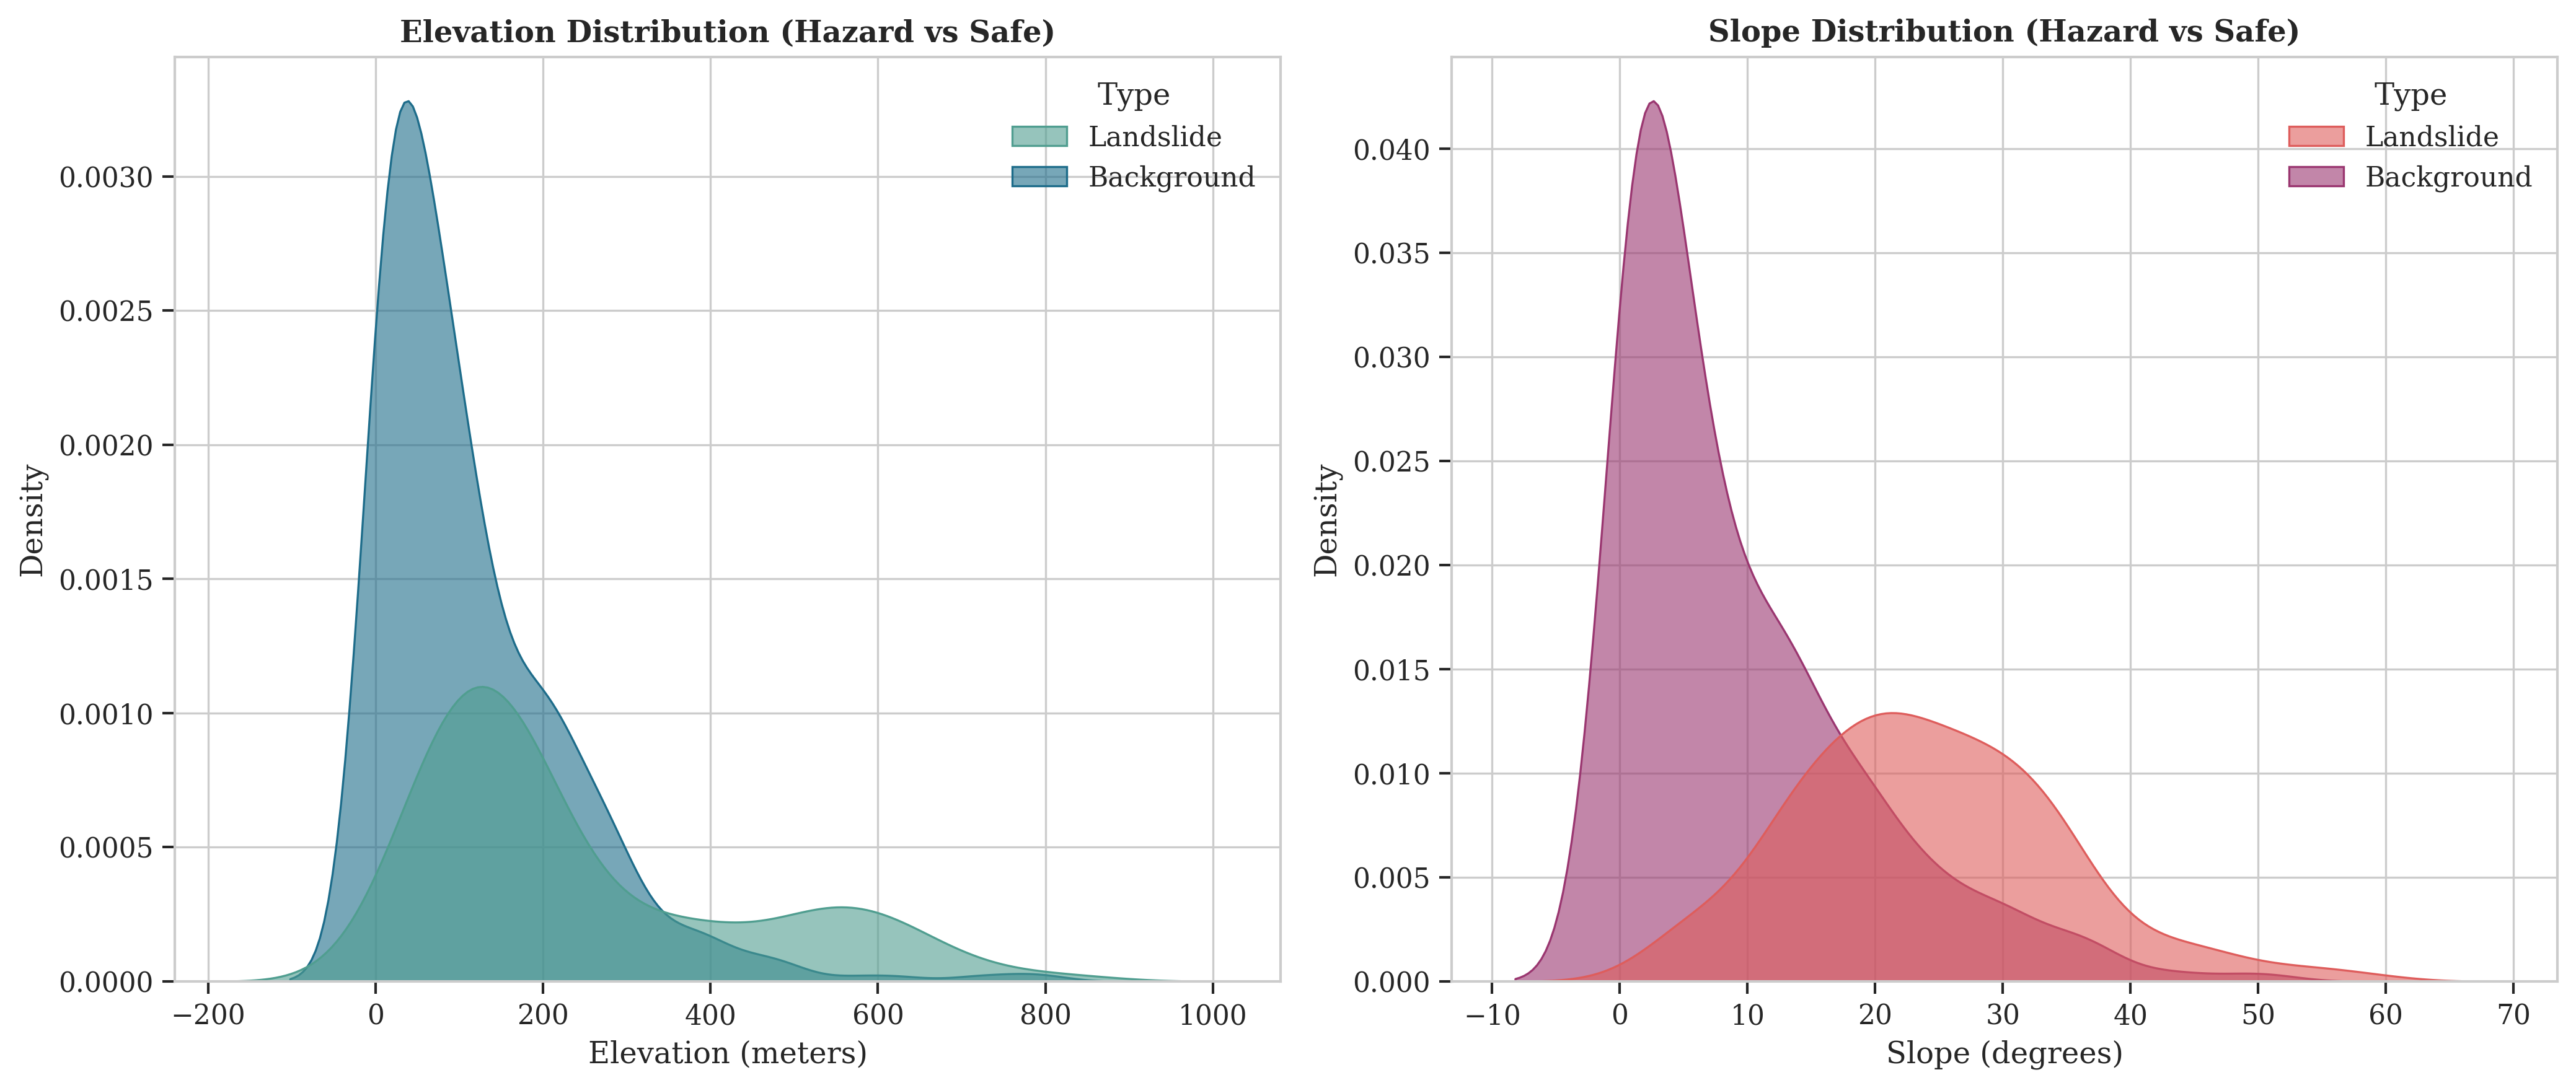

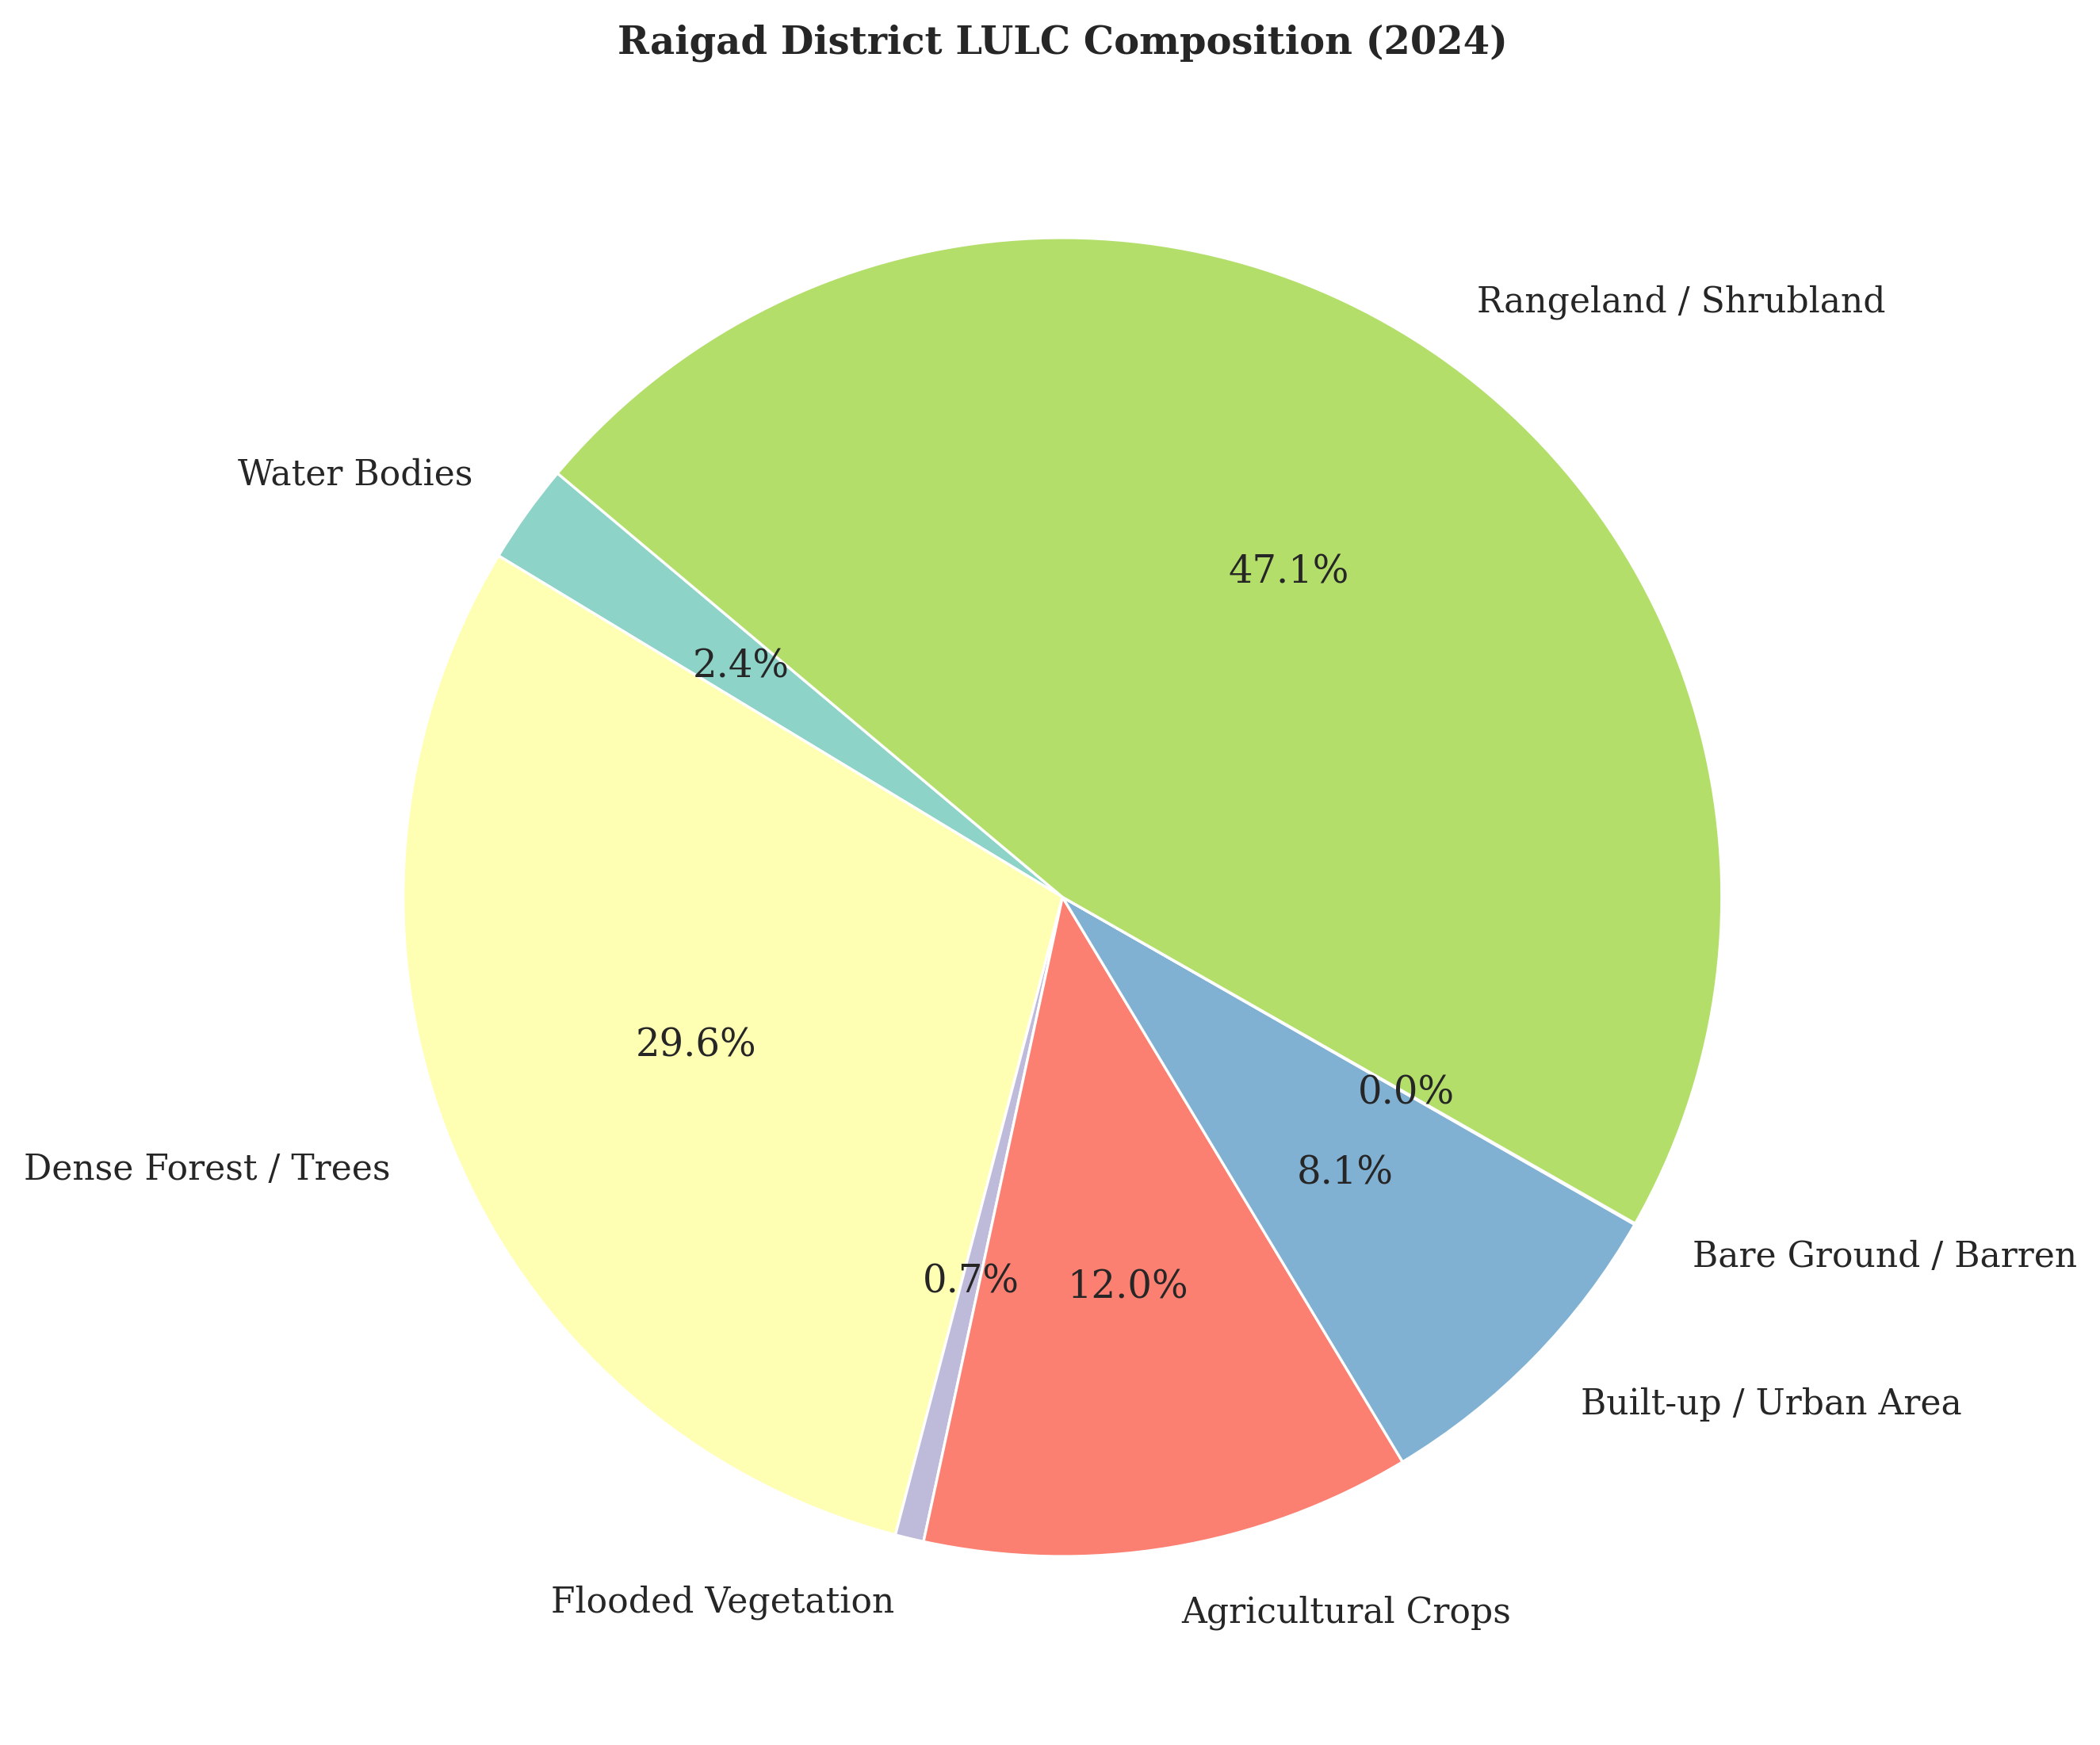

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Explicitly define the directory where the previous script saved the CSVs
OUT_DIR = "/kaggle/working/outputs_publication"

def inspect_dataset():
    print("[INFO] Generating Pre-Visualizations for BTP Report...")
    
    # 1. Distribution of Conditioning Factors (Landslide vs Background)
    topo_path = os.path.join(OUT_DIR, "Table_Topographic_Benchmark.csv")
    if os.path.exists(topo_path):
        topo_df = pd.read_csv(topo_path)
        plt.figure(figsize=(14, 6))
        
        plt.subplot(1, 2, 1)
        sns.kdeplot(data=topo_df, x="Elevation_m", hue="Type", fill=True, palette="crest", alpha=0.6)
        plt.title("Elevation Distribution (Hazard vs Safe)", fontweight='bold')
        plt.xlabel("Elevation (meters)")
        
        plt.subplot(1, 2, 2)
        sns.kdeplot(data=topo_df, x="Slope_deg", hue="Type", fill=True, palette="flare", alpha=0.6)
        plt.title("Slope Distribution (Hazard vs Safe)", fontweight='bold')
        plt.xlabel("Slope (degrees)")
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "Factor_Distributions.png"), dpi=300, bbox_inches="tight")
        print(" -> Saved Factor Distributions plot.")
    else:
        print(" -> Error: Topographic benchmark CSV not found.")
    
    # 2. LULC Class Dominance
    lulc_path = os.path.join(OUT_DIR, "Table_LULC_Change.csv")
    if os.path.exists(lulc_path):
        lulc_df = pd.read_csv(lulc_path)
        latest_year = lulc_df['Year'].max()
        latest_lulc = lulc_df[lulc_df['Year'] == latest_year]
        
        plt.figure(figsize=(9, 9))
        colors = sns.color_palette("Set3", len(latest_lulc))
        plt.pie(latest_lulc['Percentage'], labels=latest_lulc['Class_Name'], 
                autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
        plt.title(f"Raigad District LULC Composition ({latest_year})", fontweight='bold')
        
        plt.savefig(os.path.join(OUT_DIR, f"LULC_Pie_{latest_year}.png"), dpi=300, bbox_inches="tight")
        print(f" -> Saved LULC Pie Chart for {latest_year}.")
    else:
        print(" -> Error: LULC change CSV not found.")
        
    print("[SUCCESS] Inspection complete. Check the outputs folder.")

# Run the function
inspect_dataset()

## Stage 3: Save the Plots and Weights of the final model

In [8]:
import shutil
import os

print("[INFO] Preparing Final Submission Archive...")

# The three critical output directories
folders_to_zip = [
    "/kaggle/working/outputs",               # Stage 1: Base model weights & metrics
    "/kaggle/working/outputs_publication",   # Stage 2: Inspection plots, Maps, CSVs
    "/kaggle/working/geo_vqa_aligned_weights"# Stage 3: Final Multimodal Adapter weights
]

# Create a staging directory to hold everything cleanly
staging_dir = "/kaggle/working/Final_BTP_Submission"
os.makedirs(staging_dir, exist_ok=True)

# Copy all folders into the staging directory
for folder in folders_to_zip:
    if os.path.exists(folder):
        folder_name = os.path.basename(folder)
        dest_path = os.path.join(staging_dir, folder_name)
        shutil.copytree(folder, dest_path, dirs_exist_ok=True)
        print(f" -> Successfully copied '{folder_name}' to archive.")
    else:
        print(f" -> WARNING: Directory {folder} not found.")

# Zip the staging directory
final_zip_path = "/kaggle/working/Final_BTP_Submission"
shutil.make_archive(final_zip_path, 'zip', staging_dir)

print(f"\n[SUCCESS] Master Archive created at: {final_zip_path}.zip")
print("You can now download this file from the Kaggle output panel to view your plots!")

[INFO] Preparing Final Submission Archive...
 -> Successfully copied 'outputs' to archive.
 -> Successfully copied 'outputs_publication' to archive.
 -> Successfully copied 'geo_vqa_aligned_weights' to archive.

[SUCCESS] Master Archive created at: /kaggle/working/Final_BTP_Submission.zip
You can now download this file from the Kaggle output panel to view your plots!
